In [19]:
import pandas as pd
import numpy as np


In [21]:
# Load your merged CSV
file_path = "/content/drive/MyDrive/GEE_Forest_TimeSeries/kerelakerela_Forest_TimeSeries_Master.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)


             system:index       BSI  Forest       NBR      NDMI      NDVI  \
0  000000000000000372c9_0 -0.135493       1  0.474257  0.205954  0.645937   
1  000000000000000372c9_0 -0.166156       1  0.412070  0.222653  0.559809   
2  000000000000000372c9_0 -0.095108       1  0.364489  0.173764  0.415404   
3  000000000000000372c9_0 -0.158557       1  0.404293  0.224158  0.509308   
4  000000000000000372ca_0 -0.116051       1  0.427636  0.165637  0.650483   

   year                                               .geo  longitude  \
0  2021  {"geodesic":false,"type":"Point","coordinates"...  76.783948   
1  2022  {"geodesic":false,"type":"Point","coordinates"...  76.783948   
2  2023  {"geodesic":false,"type":"Point","coordinates"...  76.783948   
3  2024  {"geodesic":false,"type":"Point","coordinates"...  76.783948   
4  2021  {"geodesic":false,"type":"Point","coordinates"...  76.804609   

   latitude  
0  9.217164  
1  9.217164  
2  9.217164  
3  9.217164  
4  9.217164  
Index(['system

In [22]:
features = ['NDVI', 'NDMI', 'NBR', 'BSI']
df = df[['latitude', 'longitude', 'year'] + features]

df = df.dropna()


In [23]:
df = df.sort_values(by=['latitude', 'longitude', 'year'])


In [24]:
df[['year', 'NDVI', 'BSI']].groupby('year').describe()


NDVI                                                              \
        count      mean       std       min       25%       50%       75%   
year                                                                        
2021  30000.0  0.818427  0.044222  0.318878  0.802641  0.828990  0.845676   
2022  30000.0  0.495978  0.046786  0.132406  0.465260  0.489317  0.525987   
2023  30000.0  0.507885  0.042811  0.125528  0.483982  0.506334  0.532922   
2024  30000.0  0.508261  0.044657  0.159715  0.480491  0.505219  0.535333   

                    BSI                                                    \
           max    count      mean       std       min       25%       50%   
year                                                                        
2021  0.910664  30000.0 -0.260858  0.062579 -0.496731 -0.302836 -0.266517   
2022  0.673910  30000.0 -0.132078  0.028654 -0.297636 -0.145887 -0.131628   
2023  0.669511  30000.0 -0.143858  0.032729 -0.302966 -0.162272 -0.147223   
2024  0.676050  30000.0 -0.144625  0.031065 -0.270751 -0.162821 -0.146192   

                          
           75%       max  
year                      
2021 -0.225041  0.245727  
2022 -0.117456  0.089068  
2023 -0.128509  0.154294  
2024 -0.128704  0.119904

In [25]:
sequence_length = 4  # 2021–2024
X = []
locations = []

for (lat, lon), group in df.groupby(['latitude', 'longitude']):
    if len(group) == sequence_length:
        X.append(group[features].values)
        locations.append([lat, lon])

X = np.array(X)
locations = np.array(locations)

print("LSTM input shape:", X.shape)


LSTM input shape: (30000, 4, 4)


In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(X.shape)

print("Normalized input shape:", X.shape)


Normalized input shape: (30000, 4, 4)


In [29]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [30]:
print("Input shape:", X.shape)


Input shape: (30000, 4, 4)


In [31]:
ndvi_change = X[:, 0, 0] - X[:, -1, 0]   # 2021 - 2024
bsi_change = X[:, -1, 3] - X[:, 0, 3]   # 2024 - 2021
ndvi_thr = np.percentile(ndvi_change, 85)
bsi_thr  = np.percentile(bsi_change, 85)

print("NDVI threshold:", ndvi_thr)
print("BSI threshold :", bsi_thr)
y = ((ndvi_change > ndvi_thr) & (bsi_change > bsi_thr)).astype(int)
print("\nLabel distribution:")
print("No deforestation:", (y == 0).sum())
print("Deforestation:", (y == 1).sum())


NDVI threshold: 0.4582813605780159
BSI threshold : 0.21666865716267436

Label distribution:
No deforestation: 27423
Deforestation: 2577


In [32]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)


{0: np.float64(0.5469861065528936), 1: np.float64(5.820721769499418)}


In [33]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=128,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9847 - loss: 0.0859 - val_accuracy: 0.9873 - val_loss: 0.0442
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9877 - loss: 0.0327 - val_accuracy: 0.9883 - val_loss: 0.0396
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9885 - loss: 0.0330 - val_accuracy: 0.9892 - val_loss: 0.0360
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9884 - loss: 0.0312 - val_accuracy: 0.9903 - val_loss: 0.0342
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9905 - loss: 0.0259 - val_accuracy: 0.9902 - val_loss: 0.0321
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9894 - loss: 0.0276 - val_accuracy: 0.9900 - val_loss: 0.0355
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9899 - loss: 0.0264 - val_accuracy: 0.9905 - val_loss: 0.0312
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9898 - loss: 0.0248 - val_accuracy

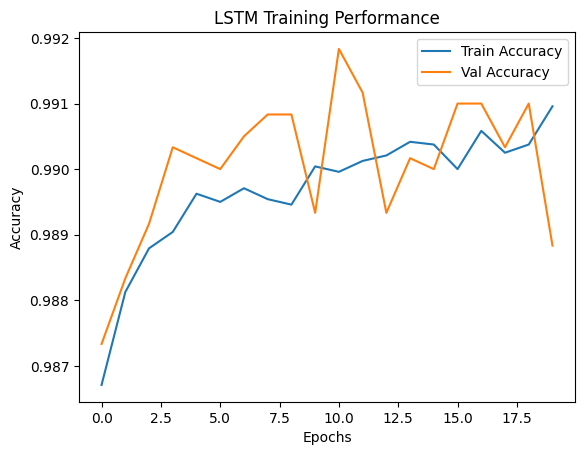

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Training Performance')
plt.show()


In [35]:
# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype(int)


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


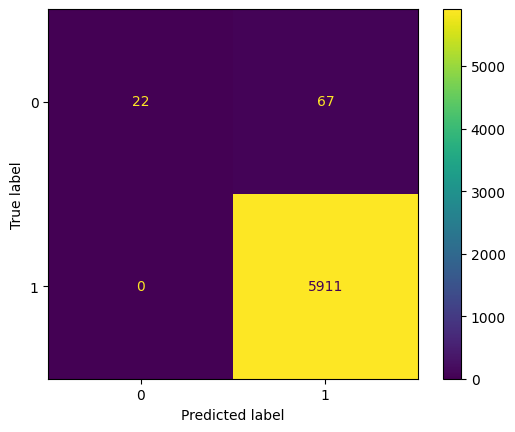

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.25      0.40        89
           1       0.99      1.00      0.99      5911

    accuracy                           0.99      6000
   macro avg       0.99      0.62      0.70      6000
weighted avg       0.99      0.99      0.99      6000



In [38]:
print("Locations shape:", locations.shape)
print("Predictions shape:", y_pred.shape)


Locations shape: (30000, 2)
Predictions shape: (6000, 1)


In [39]:
import pandas as pd

# Check shapes (for confirmation)
print("Locations:", locations.shape)
print("Predictions:", y_pred.shape)

# Match sizes safely
n = y_pred.shape[0]   # 6000

results_df = pd.DataFrame({
    'latitude': locations[:n, 0],
    'longitude': locations[:n, 1],
    'deforestation': y_pred.flatten()
})

print(results_df.head())

# Save output
results_df.to_csv('Deforestation_Predictions_kerela.csv', index=False)
print("Saved: Deforestation_Predictions.csv")


Locations: (30000, 2)
Predictions: (6000, 1)
   latitude  longitude  deforestation
0  9.217164  76.783948              1
1  9.217164  76.804609              1
2  9.217164  76.820779              1
3  9.217164  76.828864              1
4  9.217164  76.832457              1
Saved: Deforestation_Predictions.csv


In [40]:
import pandas as pd

# Make sure lengths match
n = y_pred.shape[0]  # number of predictions

results_df = pd.DataFrame({
    'latitude': locations[:n, 0],
    'longitude': locations[:n, 1],
    'deforestation': y_pred.flatten()
})

print(results_df.head())

# Save permanently to Google Drive
from google.colab import drive
drive.mount('/content/drive')

results_df.to_csv('/content/drive/MyDrive/Deforestation_Predictions_kerela.csv', index=False)
print("Saved to Google Drive: Deforestation_Predictions.csv")


   latitude  longitude  deforestation
0  9.217164  76.783948              1
1  9.217164  76.804609              1
2  9.217164  76.820779              1
3  9.217164  76.828864              1
4  9.217164  76.832457              1
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Google Drive: Deforestation_Predictions.csv
